In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#create data frame from H-alpha csv

#csv file
h_alpha_file = "./H-alpha/HI to H-alpha Classification - Sheet1.csv"

#initialize dataframe with csv
h_alpha_df = pd.read_csv(h_alpha_file)

print(h_alpha_df.columns)

Index(['Galaxy', 'Sequence Number', 'HI Hole Type', 'Classification'], dtype='object')


In [3]:
#create data frame from IRAC 8 csv

#csv file
irac_file = "./IRAC_8m/HI to IRAC 8 micron Classification - Sheet1.csv"

#initialize dataframe with csv
irac_df = pd.read_csv(irac_file)

print(irac_df.columns)

Index(['Galaxy', 'Sequence Number', 'HI Hole Type', 'Classification'], dtype='object')


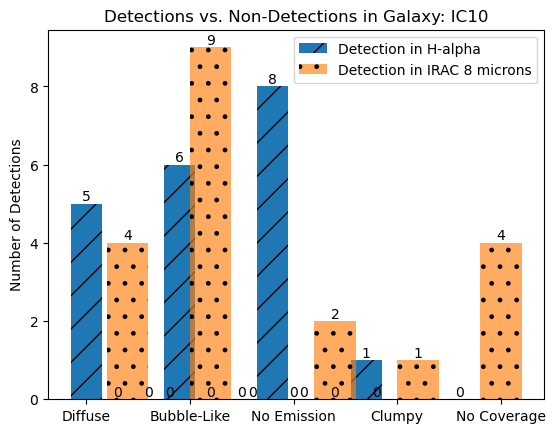

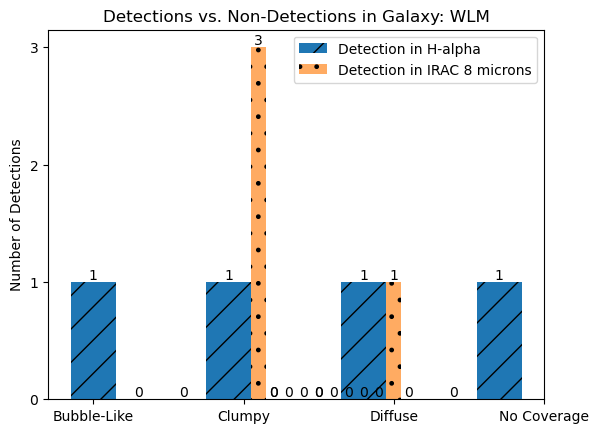

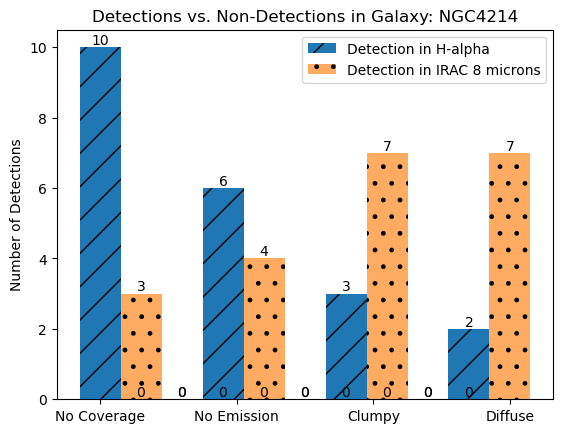

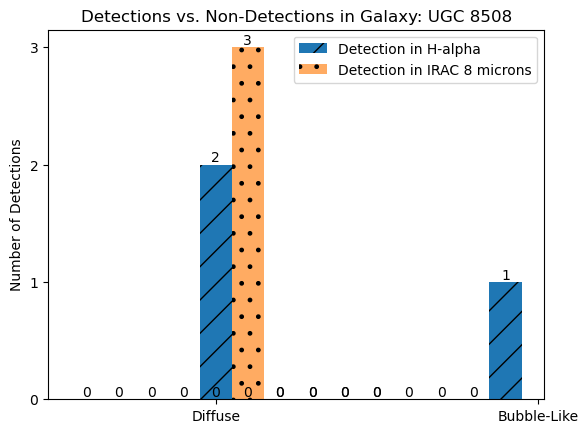

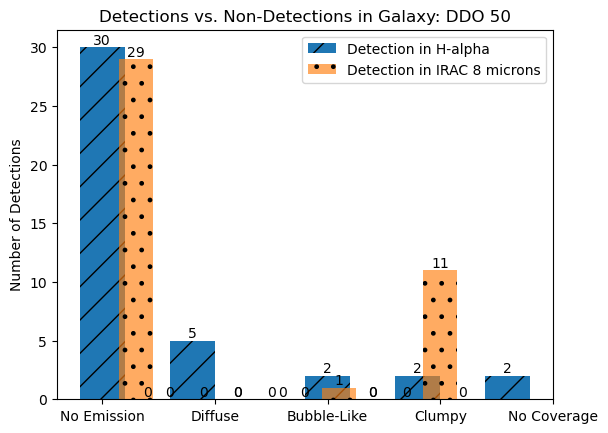

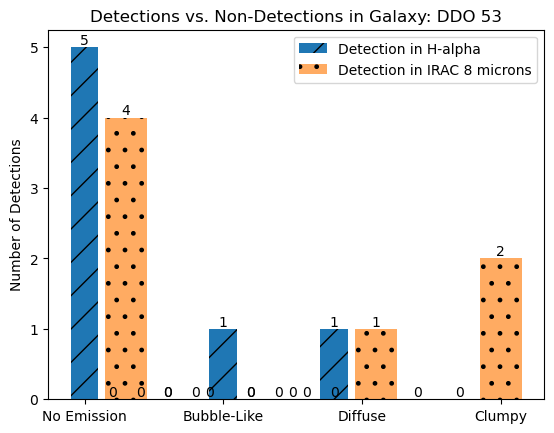

In [4]:
#create histogram

#get unique galaxies from ha_df
ha_galaxies = pd.unique(h_alpha_df["Galaxy"])
#print(ha_galaxies)

#get unique galaxies from irac_df
irac_galaxies = pd.unique(irac_df["Galaxy"])
#print(irac_galaxies)

#check if galaxies match in dfs
if not np.array_equal(ha_galaxies, irac_galaxies):
    raise ValueError("Galaxies do not match!")

#loop through galaxies and determine detection
for galaxy in ha_galaxies:

    #initilize detections tracker
    ha_detection = []
    irac_detection = []

    #iterate over rows in h_alpha_df
    for index, row in enumerate(h_alpha_df["Galaxy"]):

        #check if galaxy is unique
        if galaxy == row:

            #set detection variable
            detected = h_alpha_df["Classification"][index]
            #print(f"{galaxy}", detected)

            #add detection classification to ha_detection
            ha_detection = np.append(ha_detection, detected)

    #iterate over rows in irac_df
    for index, row in enumerate(irac_df["Galaxy"]):

        #check if galaxy is unique
        if galaxy == row:

            #set detection variable
            detected = irac_df["Classification"][index]
            #print(f"{galaxy}", detected)

            #add detection classification to detection
            irac_detection = np.append(irac_detection, detected)
    
    #plot histogram for unique galaxy
    counts, bins, patches = plt.hist(ha_detection, label="Detection in H-alpha", hatch='/', align="left")
    plt.bar_label(patches)
    counts, bins, patches = plt.hist(irac_detection, label="Detection in IRAC 8 microns", alpha=.65, hatch='.', align="right")
    plt.bar_label(patches)
    plt.locator_params(axis='y', integer=True)
    plt.title(f"Detections vs. Non-Detections in Galaxy: {galaxy}")
    plt.ylabel("Number of Detections")
    plt.legend()
    plt.show()

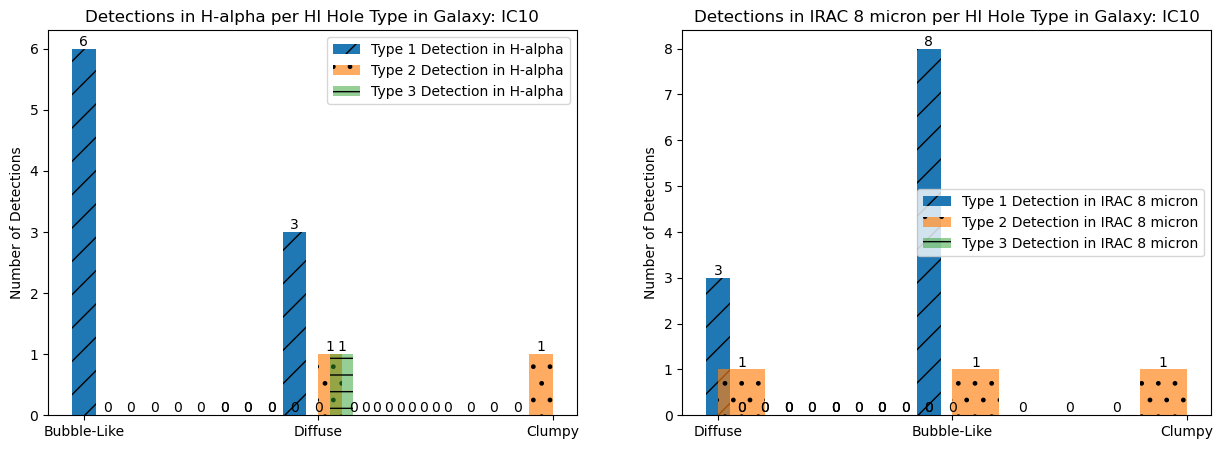

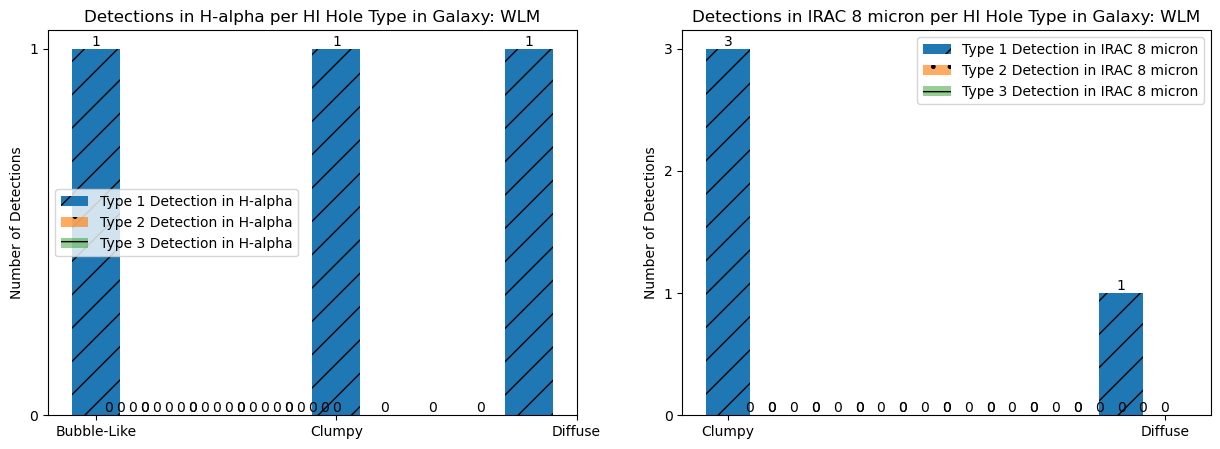

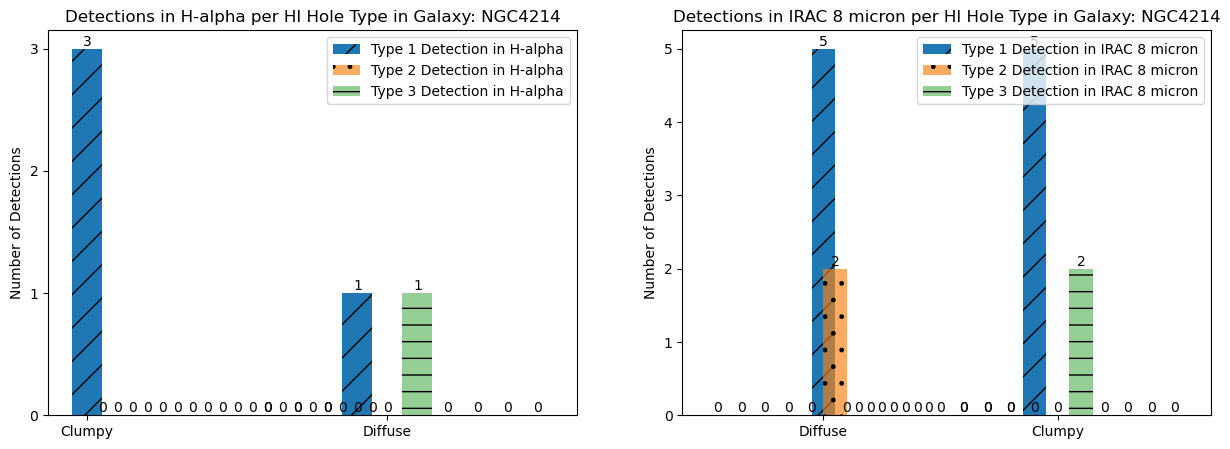

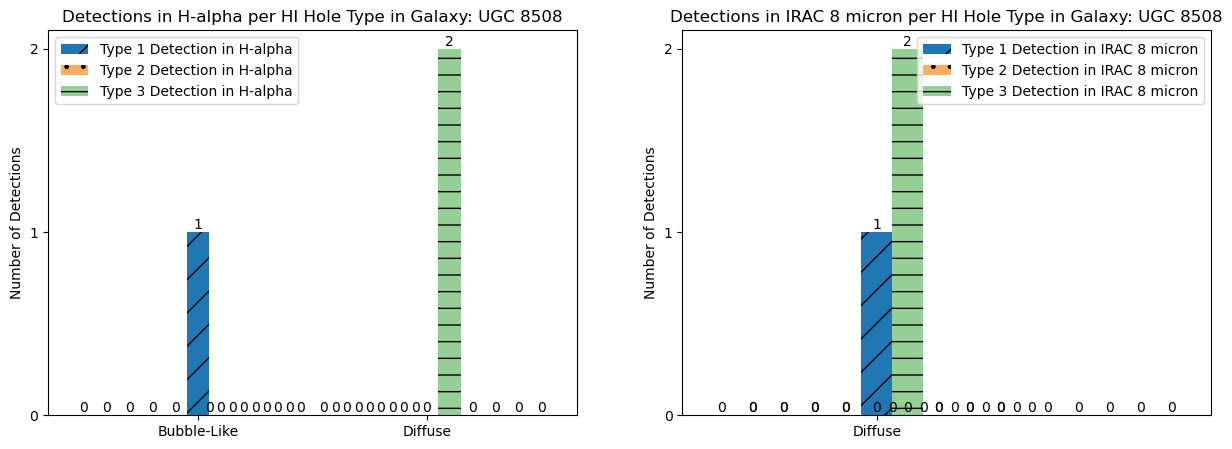

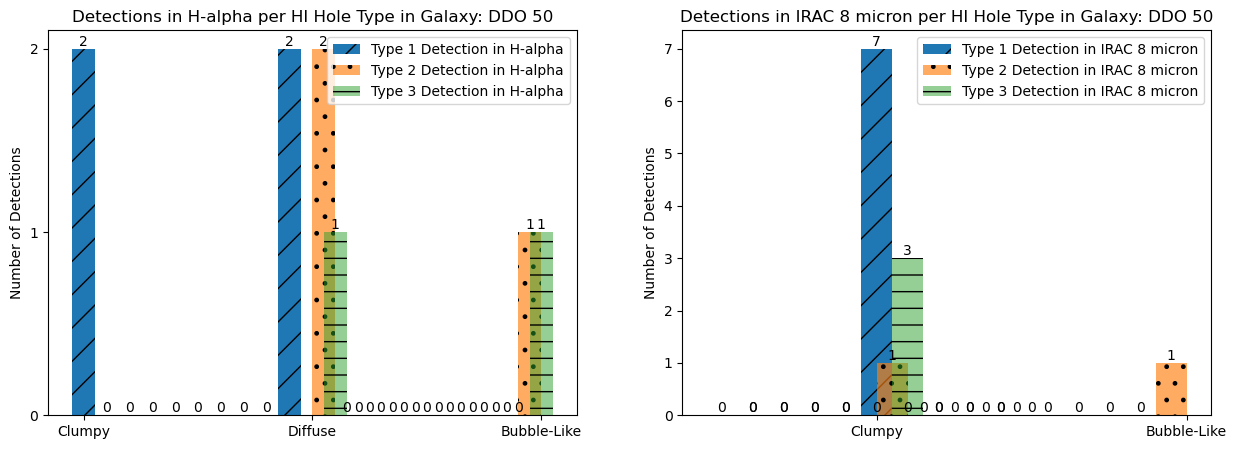

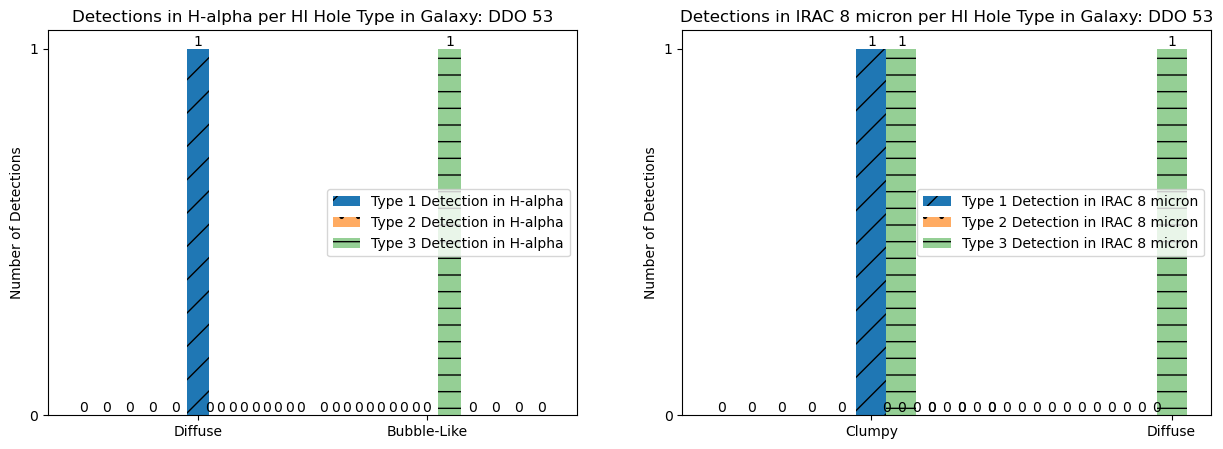

In [5]:
#compare HI type to detection

#check if galaxies match in dfs
if np.array_equal(ha_galaxies, irac_galaxies) == 0:
    raise ValueError("Galaxies do not match!")

#loop through galaxies and determine detection
for galaxy in ha_galaxies:

    #initilize detections tracker
    type_1_detection_ha = []
    type_2_detection_ha = []
    type_3_detection_ha = []
    type_1_detection_irac = []
    type_2_detection_irac = []
    type_3_detection_irac = []

    #iterate over rows in h_alpha_df
    for index, row in enumerate(h_alpha_df["Galaxy"]):

        #check if galaxy is unique
        if galaxy == row:

            #set detection variable
            detected = h_alpha_df["HI Hole Type"][index]
            #print(f"{galaxy}", detected)

            #set classification
            classification = h_alpha_df["Classification"][index]

            #check if coverage or emission
            if classification != "No Coverage" and classification != "No Emission":

                #check hole type then append classification of matching detection
                match detected:
                    case 1:
                        type_1_detection_ha = np.append(type_1_detection_ha, classification)
                    case 2:
                        type_2_detection_ha = np.append(type_2_detection_ha, classification)
                    case 3:
                        type_3_detection_ha = np.append(type_3_detection_ha, classification)

    #iterate over rows in irac_df
    for index, row in enumerate(irac_df["Galaxy"]):

        #check if galaxy is unique
        if galaxy == row:

            #set detection variable
            detected = irac_df["HI Hole Type"][index]
            #print(f"{galaxy}", detected)

            #set classification
            classification = irac_df["Classification"][index]

            #check if coverage or emission
            if classification != "No Coverage" and classification != "No Emission":

                #check hole type then append classification of matching detection
                match detected:
                    case 1:
                        type_1_detection_irac = np.append(type_1_detection_irac, classification)
                    case 2:
                        type_2_detection_irac = np.append(type_2_detection_irac, classification)
                    case 3:
                        type_3_detection_irac = np.append(type_3_detection_irac, classification)

    #print(type_1_detection, type_2_detection, type_3_detection)
    
    #plot histogram for unique galaxy
    plt.figure(figsize=(15,5))

    #plot ha
    plt.subplot(121)
    counts, bins, patches = plt.hist(type_1_detection_ha, label="Type 1 Detection in H-alpha", align="left", hatch='/')
    plt.bar_label(patches)
    counts, bins, patches = plt.hist(type_2_detection_ha, label="Type 2 Detection in H-alpha", alpha=.65, align="mid", hatch='.')
    plt.bar_label(patches)
    counts, bins, patches = plt.hist(type_3_detection_ha, label="Type 3 Detection in H-alpha", alpha=.5, align="right", hatch='-')
    plt.bar_label(patches)
    plt.locator_params(axis='y', integer=True)
    plt.title(f"Detections in H-alpha per HI Hole Type in Galaxy: {galaxy}")
    plt.ylabel("Number of Detections")
    plt.legend()

    #plot irac 8 micron
    plt.subplot(122)
    counts, bins, patches = plt.hist(type_1_detection_irac, label="Type 1 Detection in IRAC 8 micron", align="left", hatch='/')
    plt.bar_label(patches)
    counts, bins, patches = plt.hist(type_2_detection_irac, label="Type 2 Detection in IRAC 8 micron", alpha=.65, align="mid", hatch='.')
    plt.bar_label(patches)
    counts, bins, patches = plt.hist(type_3_detection_irac, label="Type 3 Detection in IRAC 8 micron", alpha=.5, align="right", hatch='-')
    plt.bar_label(patches)
    plt.locator_params(axis='y', integer=True)
    plt.title(f"Detections in IRAC 8 micron per HI Hole Type in Galaxy: {galaxy}")
    plt.ylabel("Number of Detections")
    plt.legend()

    #show figure
    plt.show()

In [6]:
#combined histogram for all galaxies

#initilize detections

#ha detections
type_1_ha_all = []
type_2_ha_all = []
type_3_ha_all = []

#irac 8 micron detections
type_1_irac_all = []
type_2_irac_all = []
type_3_irac_all = []

#iterate over rows in h_alpha_df
for index, row in enumerate(h_alpha_df["Galaxy"]):

    #set detection variable
    detected = h_alpha_df["HI Hole Type"][index]
    #print(f"{galaxy}", detected)

    #set classification
    classification = h_alpha_df["Classification"][index]

    #check if coverage or emission
    if classification != "No Coverage" and classification != "No Emission":

        #check hole type then append classification of matching detection
        match detected:
            case 1:
                type_1_ha_all = np.append(type_1_ha_all, classification)
            case 2:
                type_2_ha_all = np.append(type_2_ha_all, classification)
            case 3:
                type_3_ha_all = np.append(type_3_ha_all, classification)

#iterate over rows in irac_df
for index, row in enumerate(irac_df["Galaxy"]):

    #set detection variable
    detected = irac_df["HI Hole Type"][index]
    #print(f"{galaxy}", detected)

    #set classification
    classification = irac_df["Classification"][index]

    #check if coverage or emission
    if classification != "No Coverage" and classification != "No Emission":

        #check hole type then append classification of matching detection
        match detected:
            case 1:
                type_1_irac_all = np.append(type_1_irac_all, classification)
            case 2:
                type_2_irac_all = np.append(type_2_irac_all, classification)
            case 3:
                type_3_irac_all = np.append(type_3_irac_all, classification)

<Figure size 1500x2000 with 0 Axes>

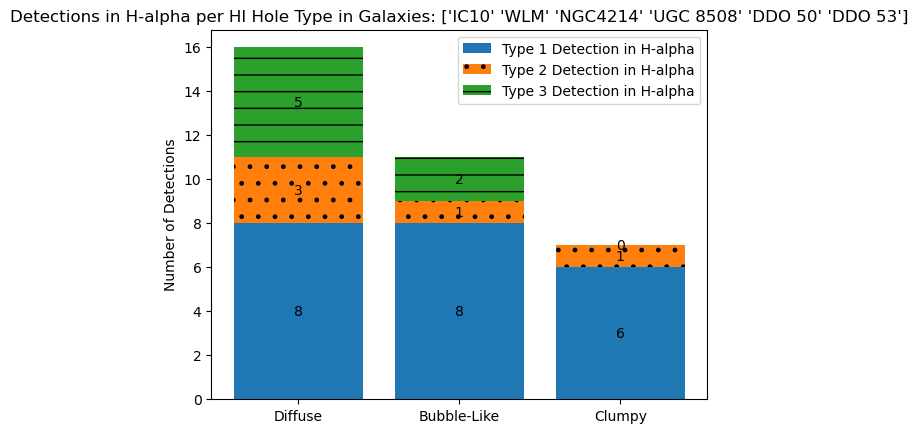

<Figure size 1500x2000 with 0 Axes>

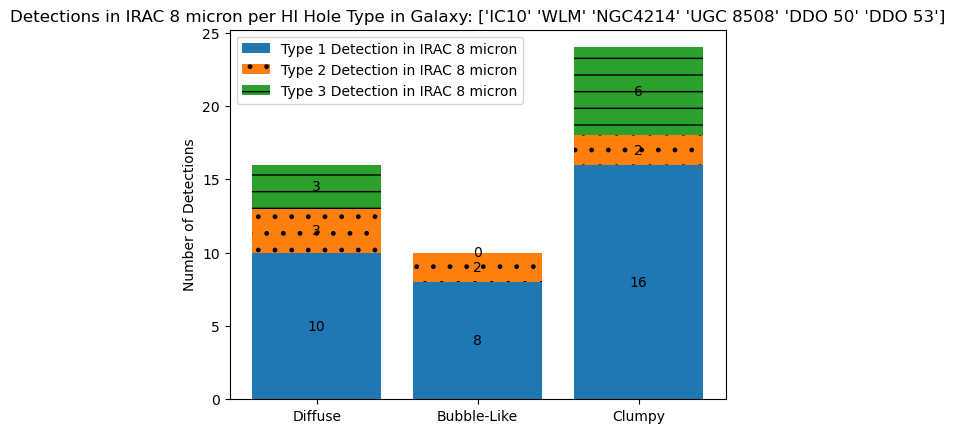

In [7]:
#plot histogram for all galaxies
#generate figure
plt.figure(figsize=(15,20))

#set parameters
label = ["Type 1 Detection in H-alpha", "Type 2 Detection in H-alpha", "Type 3 Detection in H-alpha"]
classifications = ["Diffuse", "Bubble-Like", "Clumpy"]
hatch=['/', '.', '-']
data = [type_1_ha_all, type_2_ha_all, type_3_ha_all]

#plot type 1 ha
fig, ax = plt.subplots()
type_1_data = [np.where(type_1_ha_all == "Diffuse"), np.where(type_1_ha_all == "Bubble-Like"), np.where(type_1_ha_all == "Clumpy")]
type_1_data = [len(type_1_data[0][0]), len(type_1_data[1][0]), len(type_1_data[2][0])]
type_1_bar = ax.bar(classifications, type_1_data, label=label[0])#, hatch=hatch[0])

#plot type 2 ha
type_2_data = [np.where(type_2_ha_all == "Diffuse"), np.where(type_2_ha_all == "Bubble-Like"), np.where(type_2_ha_all == "Clumpy")]
type_2_data = [len(type_2_data[0][0]), len(type_2_data[1][0]), len(type_2_data[2][0])]
type_2_bar = ax.bar(classifications, type_2_data, label=label[1], bottom=type_1_data, hatch=hatch[1])

#plot type 3 ha
type_3_data = [np.where(type_3_ha_all == "Diffuse"), np.where(type_3_ha_all == "Bubble-Like"), np.where(type_3_ha_all == "Clumpy")]
type_3_data = [len(type_3_data[0][0]), len(type_3_data[1][0]), len(type_3_data[2][0])]
type_3_bar = ax.bar(classifications, type_3_data, label=label[2], bottom=np.add(type_1_data, type_2_data), hatch=hatch[2])

# Add labels to each bar
ax.bar_label(type_1_bar, fmt='%d', label_type='center')
ax.bar_label(type_2_bar, fmt='%d', label_type='center')
ax.bar_label(type_3_bar, fmt='%d', label_type='center')

#set ha plot characteristics
plt.locator_params(axis='y', integer=True)
plt.title(f"Detections in H-alpha per HI Hole Type in Galaxies: {ha_galaxies}")
plt.ylabel("Number of Detections")
plt.legend()

#show ha figure
plt.show()

#plot irac 8 micron
#generate figure
plt.figure(figsize=(15,20))

#set parameters
label = ["Type 1 Detection in IRAC 8 micron", "Type 2 Detection in IRAC 8 micron", "Type 3 Detection in IRAC 8 micron"]
classifications = ["Diffuse", "Bubble-Like", "Clumpy"]
hatch=['/', '.', '-']
data = [type_1_irac_all, type_2_irac_all, type_3_irac_all]

#plot type 1 irac 8 micron
fig, ax = plt.subplots()
type_1_data = [np.where(type_1_irac_all == "Diffuse"), np.where(type_1_irac_all == "Bubble-Like"), np.where(type_1_irac_all == "Clumpy")]
type_1_data = [len(type_1_data[0][0]), len(type_1_data[1][0]), len(type_1_data[2][0])]
type_1_bar = ax.bar(classifications, type_1_data, label=label[0])#, hatch=hatch[0])

#plot type 2 irac 8 micron
type_2_data = [np.where(type_2_irac_all == "Diffuse"), np.where(type_2_irac_all == "Bubble-Like"), np.where(type_2_irac_all == "Clumpy")]
type_2_data = [len(type_2_data[0][0]), len(type_2_data[1][0]), len(type_2_data[2][0])]
type_2_bar = ax.bar(classifications, type_2_data, label=label[1], bottom=type_1_data, hatch=hatch[1])

#plot type 3 irac 8 micron
type_3_data = [np.where(type_3_irac_all == "Diffuse"), np.where(type_3_irac_all == "Bubble-Like"), np.where(type_3_irac_all == "Clumpy")]
type_3_data = [len(type_3_data[0][0]), len(type_3_data[1][0]), len(type_3_data[2][0])]
type_3_bar = ax.bar(classifications, type_3_data, label=label[2], bottom=np.add(type_1_data, type_2_data), hatch=hatch[2])

# Add labels to each bar
ax.bar_label(type_1_bar, fmt='%d', label_type='center')
ax.bar_label(type_2_bar, fmt='%d', label_type='center')
ax.bar_label(type_3_bar, fmt='%d', label_type='center')

#set irac 8 micron plot characteristics
plt.title(f"Detections in IRAC 8 micron per HI Hole Type in Galaxy: {irac_galaxies}")
plt.ylabel("Number of Detections")
plt.legend()

#show irac 8 micron figure
plt.show()

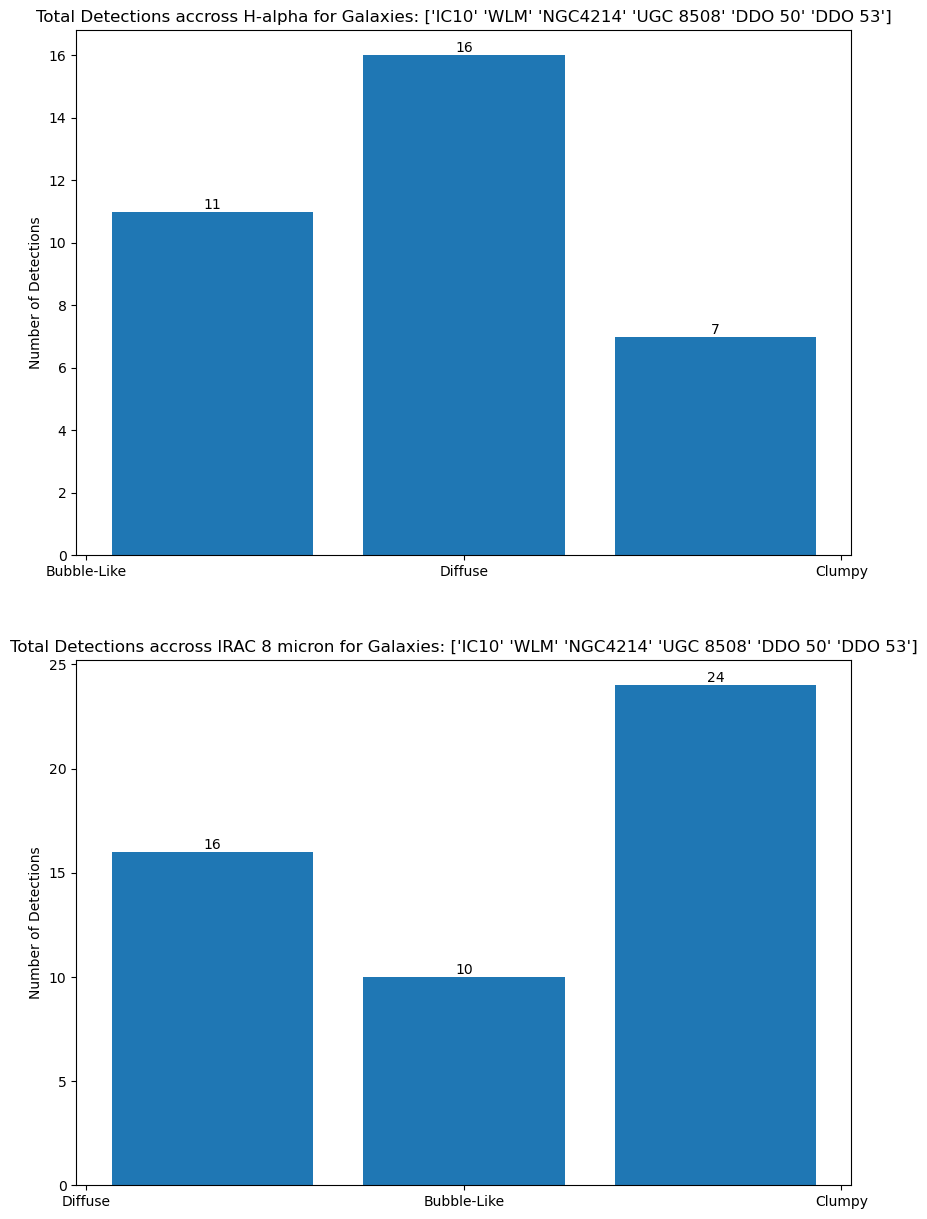

In [8]:
#create figure
plt.figure(figsize=(10,15))

#plot total detections accross Ha for all galaxies
total_ha_detections = np.concatenate((type_1_ha_all, type_2_ha_all, type_3_ha_all))
plt.subplot(211)
counts, bins, patches = plt.hist(total_ha_detections, bins=3, rwidth=.8)
plt.bar_label(patches)
plt.locator_params(axis='y', integer=True)
plt.title(f"Total Detections accross H-alpha for Galaxies: {ha_galaxies}")
plt.ylabel("Number of Detections")


#plot total detections accross irac 8 micron for all galaxies
total_irac_detections = np.concatenate((type_1_irac_all, type_2_irac_all, type_3_irac_all))
plt.subplot(212)
counts, bins, patches = plt.hist(total_irac_detections, bins=3, rwidth=.8)
plt.bar_label(patches)
plt.locator_params(axis='y', integer=True)
plt.title(f"Total Detections accross IRAC 8 micron for Galaxies: {ha_galaxies}")
plt.ylabel("Number of Detections")

#show figure
plt.show()

In [11]:
holes = len(h_alpha_df["Galaxy"])
print(f"The number of holes is {holes}")

The number of holes is 96


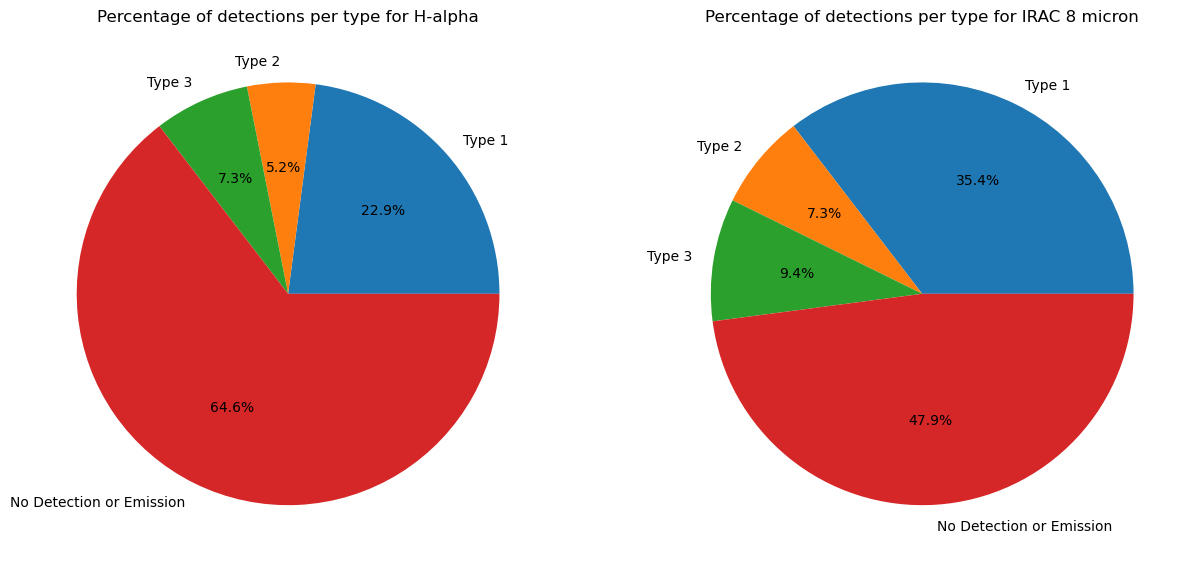

In [12]:
#percentage of detections per HI Hole type
percentage_labels = ["Type 1", "Type 2", "Type 3", "No Detection or Emission"]

#create plot
plt.figure(figsize=(15,15))

#initilize percentages
total_hi = len(h_alpha_df["Galaxy"])

#ha percentage
detections_type_1_percentage = (len(type_1_ha_all) / total_hi) * 100
detections_type_2_percentage = (len(type_2_ha_all) / total_hi) * 100
detections_type_3_percentage = (len(type_3_ha_all) / total_hi) * 100
no_detections = 100 - sum([detections_type_1_percentage, detections_type_2_percentage, detections_type_3_percentage])

#plot ha percentage
plt.subplot(121)
plt.pie([detections_type_1_percentage, detections_type_2_percentage, detections_type_3_percentage, no_detections], \
        labels=percentage_labels, autopct='%1.1f%%')
plt.title("Percentage of detections per type for H-alpha")

#irac 8 micron percentage
detections_type_1_percentage = (len(type_1_irac_all) / total_hi) * 100
detections_type_2_percentage = (len(type_2_irac_all) / total_hi) * 100
detections_type_3_percentage = (len(type_3_irac_all) / total_hi) * 100
no_detections = 100 - sum([detections_type_1_percentage, detections_type_2_percentage, detections_type_3_percentage])

#plot irac 8 micron percentages
plt.subplot(122)
plt.pie([detections_type_1_percentage, detections_type_2_percentage, detections_type_3_percentage, no_detections], \
        labels=percentage_labels, autopct='%1.1f%%')
plt.title("Percentage of detections per type for IRAC 8 micron")

#show plot
plt.show()

In [13]:
#compute passable holes for each galaxy

#initialize dictionary of passing holes
passable_holes = {}

#loop through each galaxie
for galaxy in ha_galaxies:

    #initialize array of passing indexes
    passing = []
    
    #loop through rows in data frames
    for index in range(len(h_alpha_df)):

        #check if unique galaxy
        if galaxy == h_alpha_df["Galaxy"][index] and galaxy == irac_df["Galaxy"][index]:

            #check if target is covered
            if h_alpha_df["Classification"][index] != "No Coverage": #and irac_df["Classification"][index] != "No Coverage":

                #check if target has emission
                if h_alpha_df["Classification"][index] != "No Emission": #and irac_df["Classification"][index] != "No Emission":

                    #assign hole index to passing
                    passing = np.append(passing, index)

    #assign passing to passing hole dict
    passable_holes[f"{galaxy}"] = passing

passable_holes_df = pd.DataFrame.from_dict(passable_holes, orient="index")
passable_holes_df

,0,1,2,3,4,5,6,7,8,9,10,11
IC10,0.0,1.0,2.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,14.0,16.0
WLM,20.0,21.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NGC4214,30.0,32.0,33.0,34.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UGC 8508,45.0,46.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DDO 50,57.0,60.0,61.0,63.0,65.0,67.0,70.0,75.0,76.0,NaN,NaN,NaN
DDO 53,90.0,94.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# for key in passable_holes:
#     for i in passable_holes[key]:
#         print(h_alpha_df.iloc[int(i)])

# for index in range(len(h_alpha_df)):
#     print(h_alpha_df["Classification"][index], irac_df["Classification"][index])

passing_hole_count = 0

for key in passable_holes:
    for i in passable_holes[key]:
        passing_hole_count += 1

print(passing_hole_count)

34


In [15]:
#combined histogram for all galaxies

#initilize detections
type_1_all = []
type_2_all = []
type_3_all = []

#iterate over rows in h_alpha_df
for index, row in enumerate(h_alpha_df["Galaxy"]):

    #set detection variable
    detected = h_alpha_df["HI Hole Type"][index]
    #print(f"{galaxy}", detected)

    #check hole type then append classification of matching detection
    match detected:
        case 1:
            type_1_all = np.append(type_1_all, classification)
        case 2:
            type_2_all = np.append(type_2_all, classification)
        case 3:
            type_3_all = np.append(type_3_all, classification)


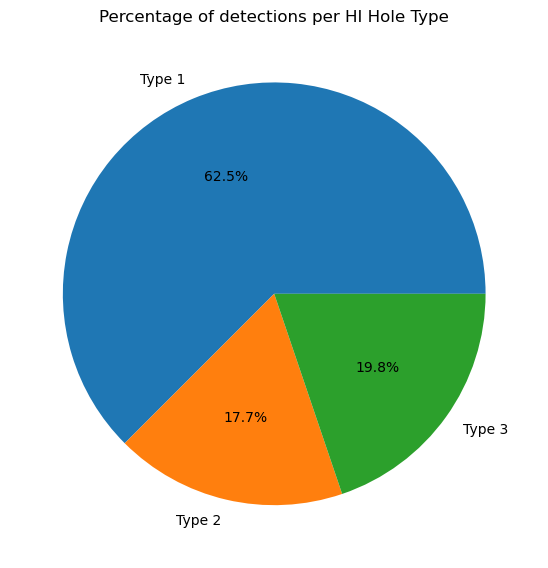

In [16]:
#percentage of detections per HI Hole type
percentage_labels = ["Type 1", "Type 2", "Type 3"]

#create plot
plt.figure(figsize=(15,15))

#initilize percentages
total = len(h_alpha_df["Galaxy"])

#percentage
detections_type_1_percentage = (len(type_1_all) / total) * 100
detections_type_2_percentage = (len(type_2_all) / total) * 100
detections_type_3_percentage = (len(type_3_all) / total) * 100

#plot percentage
plt.subplot(121)
plt.pie([detections_type_1_percentage, detections_type_2_percentage, detections_type_3_percentage], \
        labels=percentage_labels, autopct='%1.1f%%')
plt.title("Percentage of detections per HI Hole Type")

#show plot
plt.show()